In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings

warnings.filterwarnings('ignore')
sns.set_theme()
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette("Set2")

In [2]:
data = pd.read_csv('cardataset.csv')

In [26]:
data

,name,year,selling_price,km_driven,owner,mileage(km/ltr/kg),engine,max_power,seats,brand,car_age,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_encoded
0,Maruti Swift Dzire VDI,2014,450000.0,145500,First Owner,23.40,1248.0,74.00,5.0,Maruti,12,1,0,0,1,0,1,1
1,Skoda Rapid 1.5 TDI Ambition,2014,370000.0,120000,Second Owner,21.14,1498.0,103.52,5.0,Skoda,12,1,0,0,1,0,1,2
2,Honda City 2017-2020 EXi,2006,158000.0,140000,Third Owner,17.70,1497.0,78.00,5.0,Honda,20,0,0,1,1,0,1,3
3,Hyundai i20 Sportz Diesel,2010,225000.0,127000,First Owner,23.00,1396.0,90.00,5.0,Hyundai,16,1,0,0,1,0,1,1
4,Maruti Swift VXI BSIII,2007,130000.0,120000,First Owner,16.10,1298.0,88.20,5.0,Maruti,19,0,0,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000.0,110000,First Owner,18.50,1197.0,82.85,5.0,Hyundai,13,0,0,1,1,0,1,1
8124,Hyundai Verna CRDi SX,2007,135000.0,119000,Fourth & Above Owner,16.80,1493.0,110.00,5.0,Hyundai,19,1,0,0,1,0,1,4
8125,Maruti Swift Dzire ZDi,2009,382000.0,120000,First Owner,19.30,1248.0,73.90,5.0,Maruti,17,1,0,0,1,0,1,1
8126,Tata Indigo CR4,2013,290000.0,25000,First Owner,23.57,1396.0,70.00,5.0,Tata,13,1,0,0,1,0,1,1


In [27]:
data.shape

(8128, 18)

In [40]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          8128 non-null   str    
 1   year                          8128 non-null   int64  
 2   selling_price                 8128 non-null   float64
 3   km_driven                     8128 non-null   int64  
 4   mileage(km/ltr/kg)            8128 non-null   float64
 5   engine                        8128 non-null   float64
 6   max_power                     8128 non-null   float64
 7   seats                         8128 non-null   float64
 8   brand                         8128 non-null   str    
 9   car_age                       8128 non-null   int64  
 10  fuel_Diesel                   8128 non-null   int64  
 11  fuel_LPG                      8128 non-null   int64  
 12  fuel_Petrol                   8128 non-null   int64  
 13  seller_type_In

In [29]:
data.describe().astype(int)

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats,car_age,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_encoded
count,8128,8128,8128,8128,8128,8128,8128,8128,8128,8128,8128,8128,8128,8128,8128
mean,2013,515512,68311,19,1452,91,5,12,0,0,0,0,0,0,1
std,4,333702,43569,3,498,35,0,4,0,0,0,0,0,0,0
min,1983,29999,1,0,624,0,2,6,0,0,0,0,0,0,0
25%,2011,254999,35000,16,1197,68,5,9,0,0,0,1,0,1,1
50%,2015,450000,60000,19,1248,82,5,11,1,0,0,1,0,1,1
75%,2017,675000,98000,22,1582,101,5,15,1,0,1,1,0,1,2
max,2020,1305001,192500,42,3604,400,14,43,1,1,1,1,1,1,4


<Axes: xlabel='selling_price', ylabel='Count'>

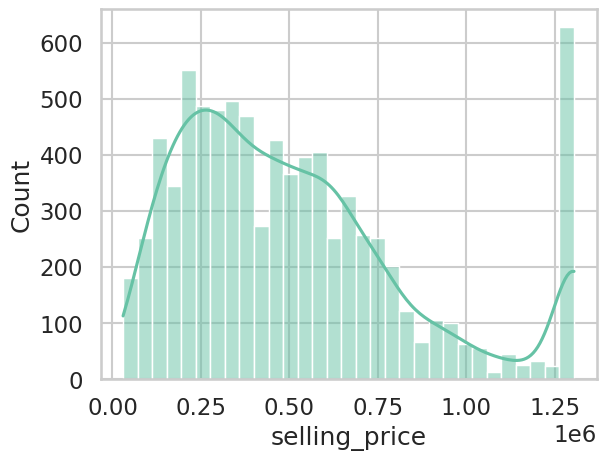

In [30]:
sns.histplot(data['selling_price'], kde=True)

In [31]:
data['selling_price'].skew()

np.float64(0.9499341684900638)

<Axes: xlabel='km_driven', ylabel='Count'>

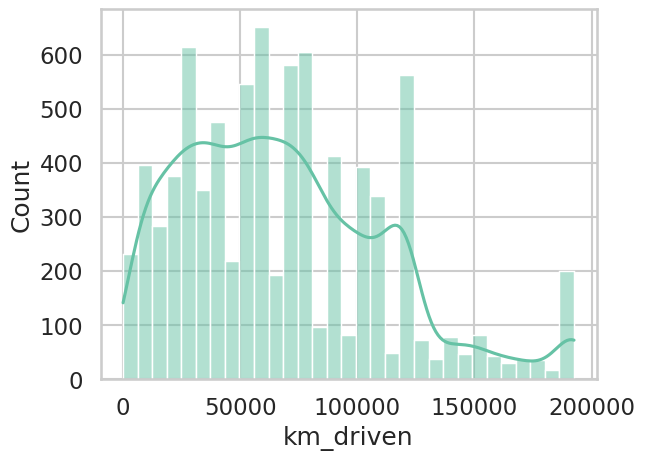

In [32]:
sns.histplot(data['km_driven'], kde=True, palette='Set2')

In [33]:
data['km_driven'].skew()

np.float64(0.7419815672914372)

In [11]:
data['mileage(km/ltr/kg)'] = data['mileage(km/ltr/kg)'].fillna(data['mileage(km/ltr/kg)'].median(), inplace= True)

In [12]:
data['engine'] = data['engine'].fillna(data['engine'].median(), inplace= True)

In [13]:
data['seats'] = data['seats'].fillna(data['seats'].median(), inplace= True)

In [14]:
data['max_power'] = data['max_power'].replace(['', ' ', 'None', 'nan'], np.nan)

In [15]:
data['max_power'] = data['max_power'].astype(float)

In [16]:
data['max_power'] = data['max_power'].fillna(data['max_power'].median(), inplace = True)

In [17]:
def extract_brand(data):
    data = data.str.split(' ')
    brands = []
    for i,name in enumerate(data):
        brand = data[i][0]
        brands.append(brand)
    return brands

data['brand'] = extract_brand(data['name'])

<Axes: ylabel='selling_price'>

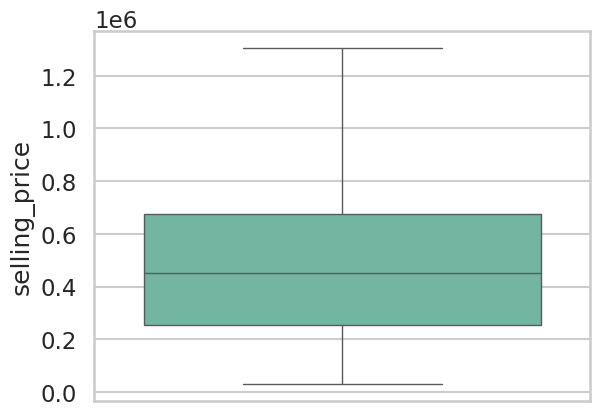

In [34]:
sns.boxplot(data['selling_price'])

<Axes: ylabel='km_driven'>

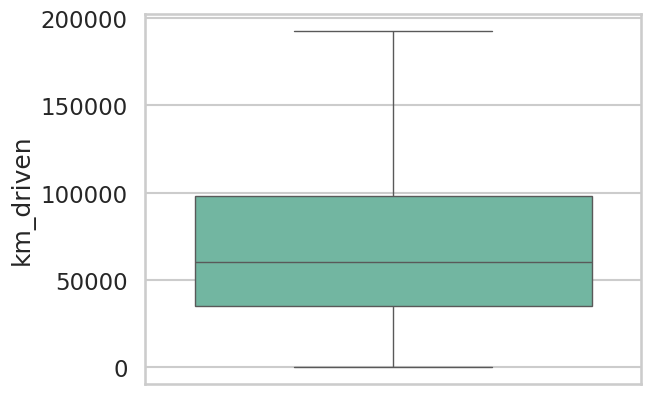

In [35]:
sns.boxplot(data['km_driven'])

In [20]:

def clip_outliers(col):
    q1 = np.percentile(col,25)
    q3 = np.percentile(col,75)
    iqr = q3 - q1
    ub = q3 + (iqr * 1.5)
    lb = q1 - (iqr * 1.5)
    
    return np.clip(col, lb, ub)
    
data['selling_price'] = clip_outliers(data['selling_price'])
data['km_driven'] = clip_outliers(data['km_driven'])

In [21]:
data['car_age'] = 2026 - data['year']

In [22]:
# Fuel, Seller Type aur Transmission par One-Hot Encoding lagao
encoded_data = pd.get_dummies(data, columns=['fuel', 'seller_type', 'transmission'], drop_first=True)

# Note: drop_first=True lagane se dummy variable trap nahi hota (aik column automatic drop ho jata hai jo safe hota hai


In [23]:
data = pd.get_dummies(data, columns=['fuel', 'seller_type', 'transmission'], drop_first=True, dtype=int)

In [24]:
owner_map = {
    'Test Drive Car': 0,
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4
}
data['owner_encoded'] = data['owner'].map(owner_map)

In [36]:
data = data.drop(columns=['owner'])

In [43]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          8128 non-null   str    
 1   year                          8128 non-null   int64  
 2   selling_price                 8128 non-null   float64
 3   km_driven                     8128 non-null   int64  
 4   mileage(km/ltr/kg)            8128 non-null   float64
 5   engine                        8128 non-null   float64
 6   max_power                     8128 non-null   float64
 7   seats                         8128 non-null   float64
 8   brand                         8128 non-null   str    
 9   car_age                       8128 non-null   int64  
 10  fuel_Diesel                   8128 non-null   int64  
 11  fuel_LPG                      8128 non-null   int64  
 12  fuel_Petrol                   8128 non-null   int64  
 13  seller_type_In

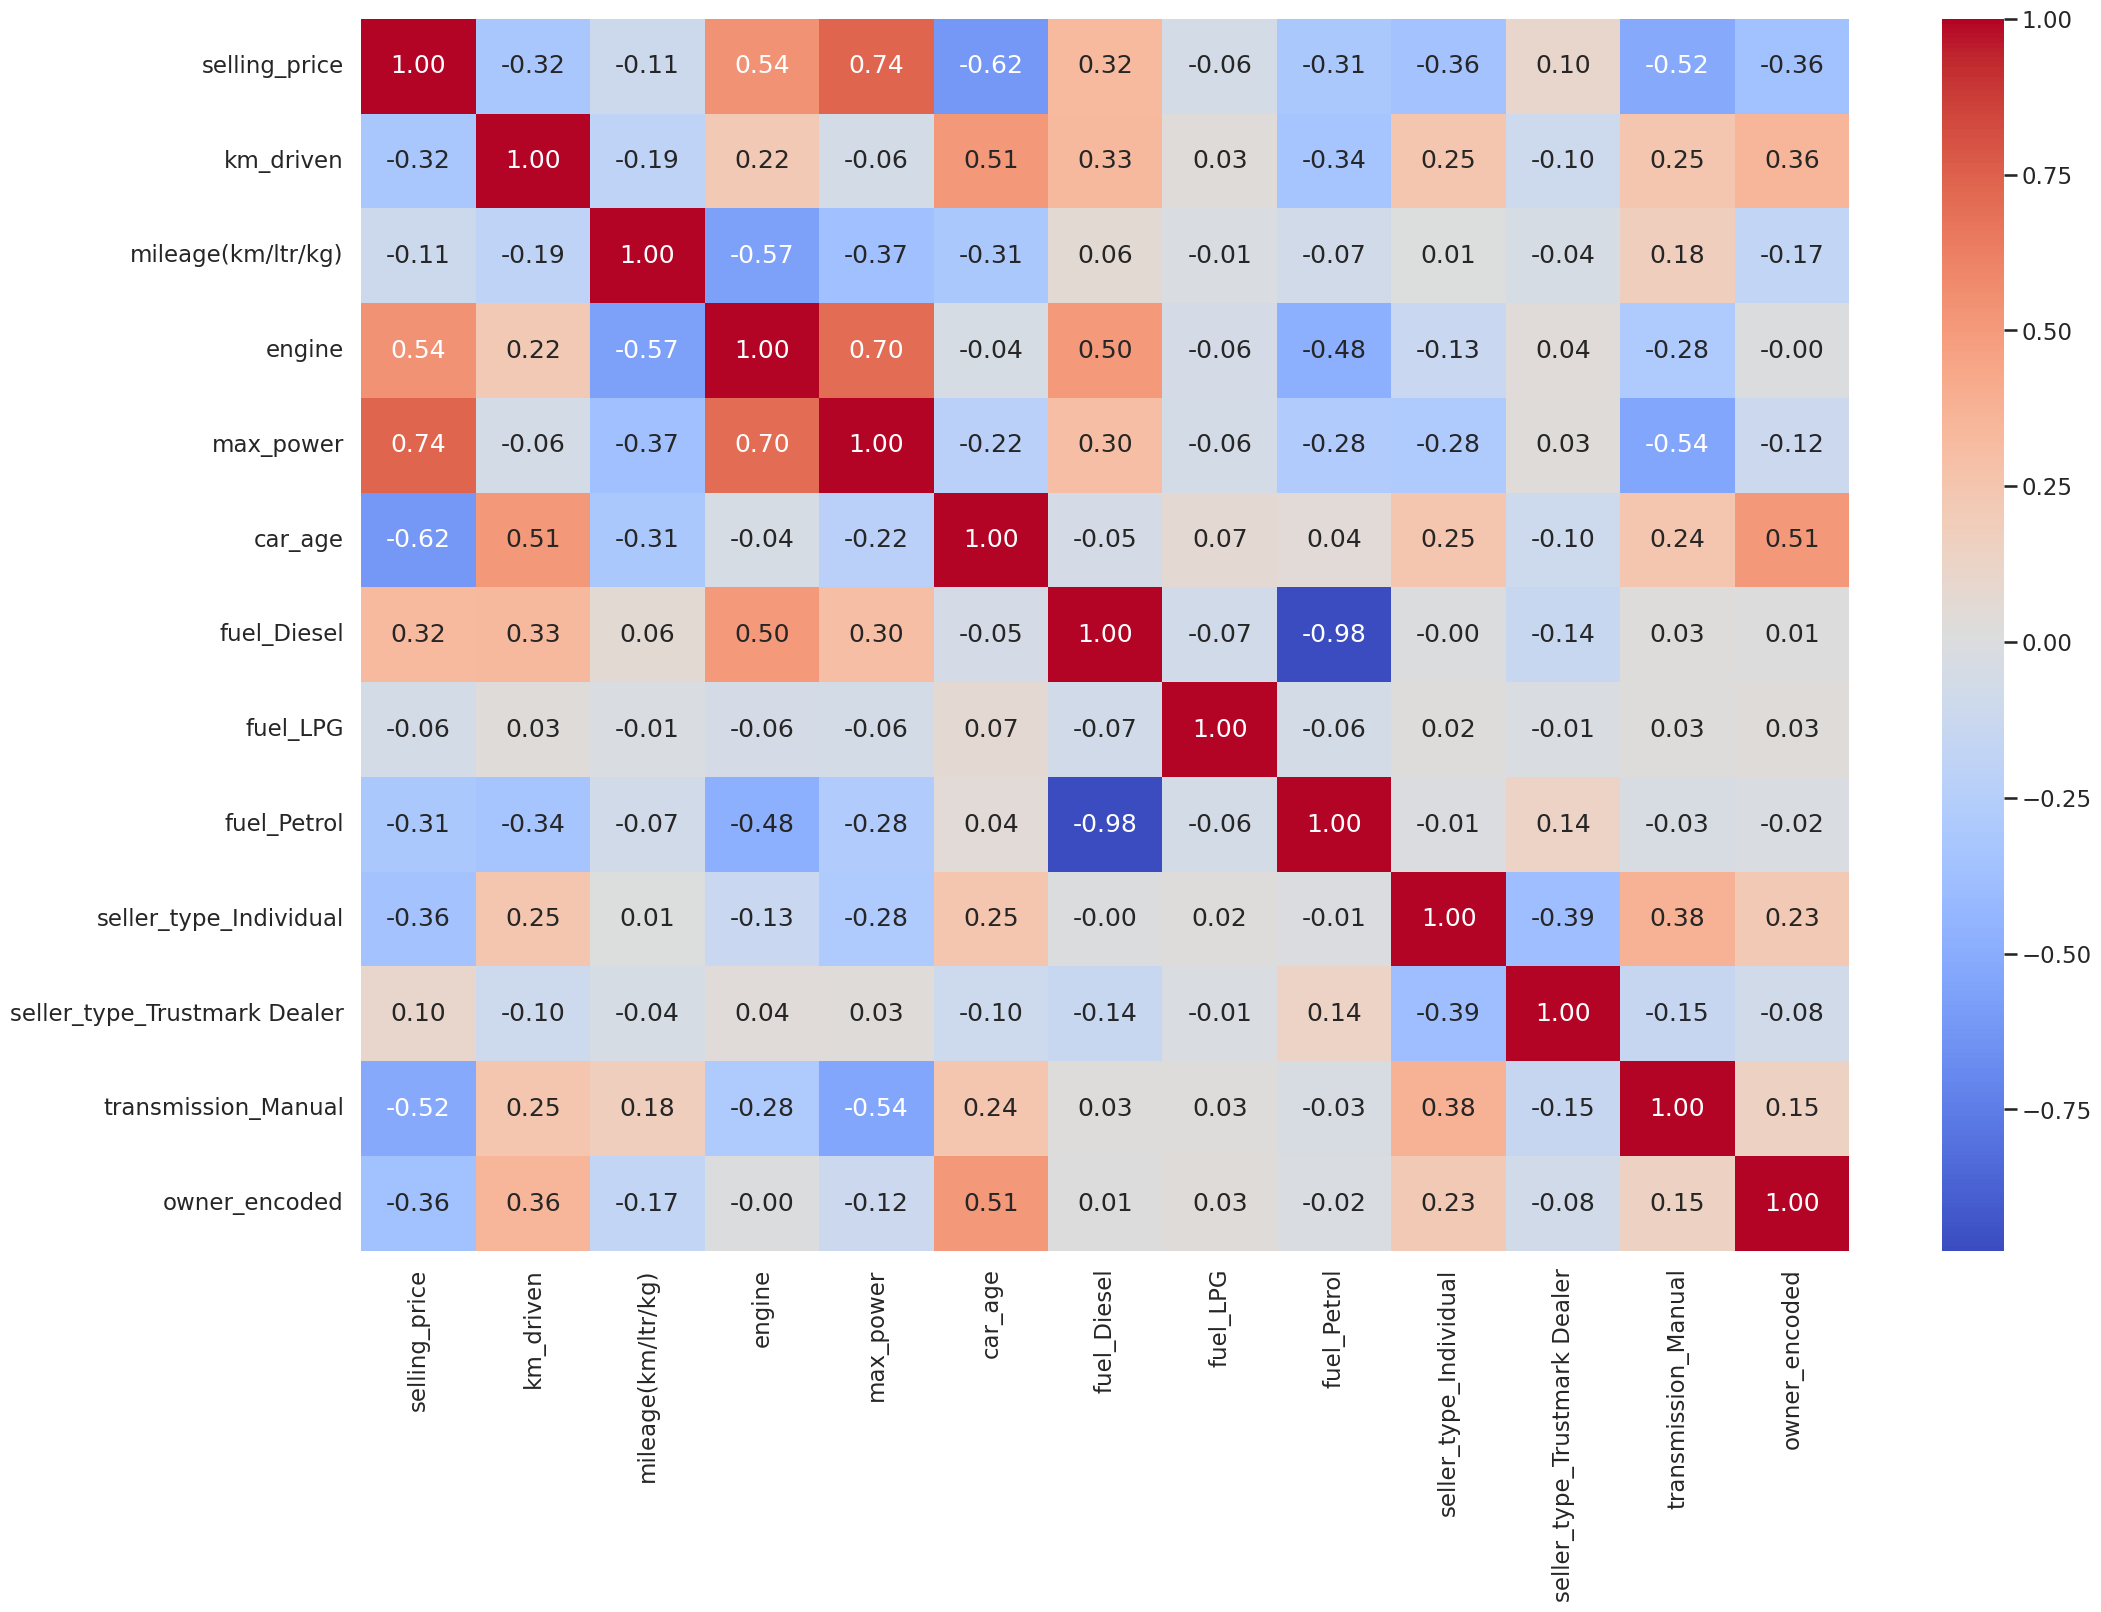

In [42]:
cor = data[['selling_price', 'km_driven', 'mileage(km/ltr/kg)',
       'engine', 'max_power', 'car_age', 'fuel_Diesel',
       'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_encoded']].corr()
plt.figure(figsize=(24, 16))
sns.heatmap(cor, annot = True, cmap= 'coolwarm',fmt=".2f")
plt.show()